# CRAG Implementation: Clustering for Data Reduction
## CSCI 4380 - Data Mining Final Project

**Research Paper:** [Clustered Retrieved Augmented Generation (CRAG)](https://arxiv.org/html/2406.00029v1)  
**Published:** May 24, 2024  
**Dataset:** Amazon Unlocked Mobile Reviews (413,841 entries)

---

### Project Overview

This notebook implements the **clustering part** of the CRAG (Clustered Retrieved Augmented Generation) pipeline. The goal is to demonstrate if  clustering algorithms can significantly reduce data volume while preserving data quality.

### Key Objectives

1. **Semantic Clustering:** Group similar reviews using K-Means (k=4 like CRAG paper)
2. **Data Reduction:** Quantify the reduction achieved by representing each cluster with one review
3. **Quality Evaluation:** Measure clustering quality using silhouette scores
4. **Comparison:** Compare K-Means with Hierarchical clustering

### Methodology

- **Embeddings:** Use `paraphrase-multilingual-mpnet-base-v2` model (768-dim vectors)
- **Clustering:** Apply K-Means separately to each product's reviews
- **Evaluation:** Silhouette score and data reduction percentage
- **Preprocessing:** Filter products with sufficient reviews for meaningful clustering





In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from tqdm import tqdm


In [2]:
"""
Step 1: Load and Explore the Dataset

Load the Amazon mobile phone reviews dataset and perform initial exploration.
"""

# Load the CSV file
data_path = "Amazon_Unlocked_Mobile.csv"
df = pd.read_csv(data_path)

# Display basic information
print(f"Total entries: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Get basic statistics
print(f"\nDataset shape: {df.shape}")
print(f"Unique products: {df['Product Name'].nunique():,}")

Total entries: 413,840

Columns: ['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']

Missing values per column:
Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

Dataset shape: (413840, 6)
Unique products: 4,410


In [3]:
"""
Step 2: Data Preprocessing

Clean the data by:
1. Keeping only necessary columns (Product Name, Rating, Reviews)
2. Removing rows with missing review text
3. Analyzing review distribution per product
"""

# Keep only the columns we need and remove missing values
df_clean = df[['Product Name', 'Rating', 'Reviews']].copy()
df_clean = df_clean.dropna(subset=['Reviews'])  # Remove entries without reviews

print(f"After removing missing reviews:")
print(f"  Total entries: {len(df_clean):,}")
print(f"  Unique products: {df_clean['Product Name'].nunique():,}")

# Count reviews per product to identify products with enough data for clustering
reviews_per_product = df_clean['Product Name'].value_counts()

print(f"\nReview distribution statistics:")
print(f"Mean reviews per product: {reviews_per_product.mean():.2f}")
print(f"Median reviews per product: {reviews_per_product.median():.0f}")
print(f"Max reviews for a product: {reviews_per_product.max():,}")
print(f"Min reviews for a product: {reviews_per_product.min():,}")

# Show top 10 products with most reviews
print(f"\nTop 10 products by review count:")
print(reviews_per_product.head(10))

After removing missing reviews:
  Total entries: 413,770
  Unique products: 4,410

Review distribution statistics:
Mean reviews per product: 93.83
Median reviews per product: 18
Max reviews for a product: 1,448
Min reviews for a product: 1

Top 10 products by review count:
Product Name
Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP Camera, White (Certified Refurbished)          1448
Apple MF259LL/A - iPhone 4s 8GB / 8MP Camera - Unlocked - Black (Certified Refurbished)       1238
BLU Studio 5.0 C HD Unlocked Cellphone, Black                                                 1194
OtterBox Iphone 5/5S/SE Defender Case w/ Drop and Dust Proctection - Realtree AP Pink         1129
Motorola Moto E (1st Generation) - Black - 4 GB - Global GSM Unlocked Phone                   1126
Apple iPhone 5s 32GB (Silver) - AT&T                                                          1118
BLU Energy X Plus Smartphone - With 4000 mAh Super Battery- US GSM Unlocked - Grey            1111
Samsung Galaxy S Duo

After filtering (min 20 reviews per product):
Products remaining: 2,159
Total reviews: 398,704
Average reviews per product: 184.67


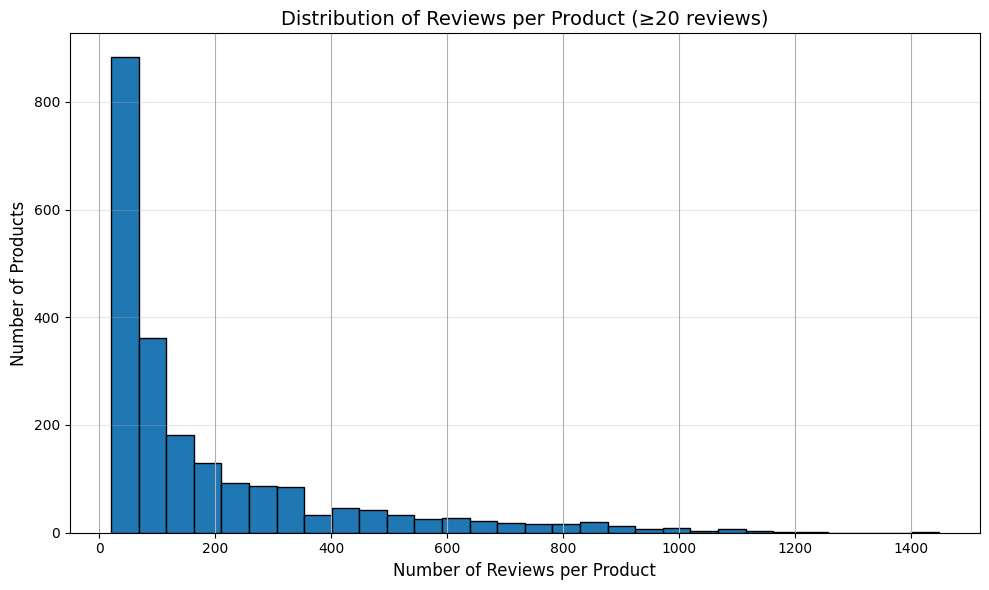


Top 5 products for clustering:
Product Name
Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP Camera, White (Certified Refurbished)       1448
Apple MF259LL/A - iPhone 4s 8GB / 8MP Camera - Unlocked - Black (Certified Refurbished)    1238
BLU Studio 5.0 C HD Unlocked Cellphone, Black                                              1194
OtterBox Iphone 5/5S/SE Defender Case w/ Drop and Dust Proctection - Realtree AP Pink      1129
Motorola Moto E (1st Generation) - Black - 4 GB - Global GSM Unlocked Phone                1126
Name: count, dtype: int64


In [4]:
"""
Step 3: Filter Products for Meaningful Clustering

Select products with sufficient reviews for clustering analysis.
The CRAG paper uses k=4 clusters, so we need products with at least 4 reviews.
For better clustering quality we'll pick 20
"""

# Set minimum review threshold (must be >= k=4 for clustering)
# Using a higher threshold ensures more meaningful clusters
min_reviews_per_product = 20

# Filter products that meet the minimum review count
products_with_enough_reviews = reviews_per_product[reviews_per_product >= min_reviews_per_product]
valid_product_names = products_with_enough_reviews.index

# Filter the dataframe to only include these products
df_filtered = df_clean[df_clean['Product Name'].isin(valid_product_names)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"After filtering (min {min_reviews_per_product} reviews per product):")
print(f"Products remaining: {df_filtered['Product Name'].nunique():,}")
print(f"Total reviews: {len(df_filtered):,}")
print(f"Average reviews per product: {len(df_filtered) / df_filtered['Product Name'].nunique():.2f}")

# Visualize the distribution of reviews per product
plt.figure(figsize=(10, 6))
products_with_enough_reviews.hist(bins=30, edgecolor='black')
plt.xlabel('Number of Reviews per Product', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.title(f'Distribution of Reviews per Product (≥{min_reviews_per_product} reviews)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 products for clustering:")
print(df_filtered['Product Name'].value_counts().head())

In [5]:
"""
Step 4: Generate Embeddings using Sentence Transformers

Convert review text into vector embeddings using the same model from the CRAG paper.

This transforms unstructured text into numerical vectors where semantically
similar reviews are close together in vector space
"""


# -----------------------------------------------------------------------------------
BATCH_LIMIT_ENABLED = True  # Set False to use the full data set
MAX_BATCHES_FOR_TESTING = 100 # Number of batches to process if batch limiting is enabled
# -----------------------------------------------------------------------------------

# Load the pre-trained sentence transformer model (same as CRAG paper)
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

print(f"Loading sentence transformer model: {model_name}")
print("This may take a moment on first run (downloading model)...")
model = SentenceTransformer(model_name)

# Prepare review texts for embedding
# Apply batch limit if enabled for testing purposes
if BATCH_LIMIT_ENABLED:
    # Calculate how many reviews correspond to MAX_BATCHES_FOR_TESTING
    # The batch_size in model.encode is 64, so N reviews = N / batch_size batches
    reviews_to_process = MAX_BATCHES_FOR_TESTING * 64
    if reviews_to_process > len(df_filtered):
        reviews_to_process = len(df_filtered) # Don't exceed available reviews

    df_for_embedding = df_filtered.head(reviews_to_process).copy()
    print(f"BATCH LIMIT ENABLED: Processing {reviews_to_process:,} reviews (approx {MAX_BATCHES_FOR_TESTING} batches) for testing")
else:
    df_for_embedding = df_filtered.copy()

review_texts = df_for_embedding['Reviews'].tolist()
print(f"\nEncoding {len(review_texts):,} reviews into embeddings...")
print("This may take a few minutes depending on hardware...")

# Generate embeddings with progress bar
# Each review becomes a 768-dimensional vector
embeddings = model.encode(
    review_texts,
    batch_size=64,  # Process 64 reviews at a time (adjust based on memory)
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"\nEmbedding generation complete!")
print(f"Shape: {embeddings.shape}")
print(f"Each review is now represented as a {embeddings.shape[1]}-dimensional vector")
print(f"Memory size: ~{embeddings.nbytes / (1024**2):.2f} MB")

# If batch limit was enabled, update df_filtered to reflect the subset used for embeddings.
# This ensures consistency for operations after this
if BATCH_LIMIT_ENABLED:
    df_filtered = df_for_embedding
    print(f"DataFrame 'df_filtered' has been updated to {len(df_filtered):,} reviews due to batch limit.")

Loading sentence transformer model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
This may take a moment on first run (downloading model)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BATCH LIMIT ENABLED: Processing 6,400 reviews (approx 100 batches) for testing

Encoding 6,400 reviews into embeddings...
This may take a few minutes depending on hardware...


Batches:   0%|          | 0/100 [00:00<?, ?it/s]


Embedding generation complete!
Shape: (6400, 768)
Each review is now represented as a 768-dimensional vector
Memory size: ~18.75 MB
DataFrame 'df_filtered' has been updated to 6,400 reviews due to batch limit.


In [6]:
"""
Step 5: K-Means Clustering (Per Product)

Apply K-Means clustering separately to each product's reviews.
Following the CRAG paper, we use k=4 clusters per product.

Each product gets its own clustering, grouping semantically similar reviews together.
"""

# Initialize cluster assignment column
df_filtered['cluster_id'] = -1  # -1 indicates not yet clustered/ invalid cluster

# Set k=4 as used in the CRAG paper
k = 4

# Get unique product names for clustering
unique_products = df_filtered['Product Name'].unique()
print(f"Clustering reviews for {len(unique_products):,} products...")
print(f"Using K-Means with k={k} clusters per product\n")

# Track clustering statistics
successfully_clustered = 0
skipped_products = 0

# Cluster each product's reviews separately
for product_name in tqdm(unique_products, desc="Clustering products"):
    # Get indices of all reviews for this product
    product_indices = df_filtered.index[df_filtered['Product Name'] == product_name].to_numpy()

    # Skip if fewer reviews than k (can't create k clusters)
    if len(product_indices) < k:
        skipped_products += 1
        continue

    # Extract embeddings for this product's reviews
    product_embeddings = embeddings[product_indices]

    # Apply K-Means clustering
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    cluster_labels = kmeans.fit_predict(product_embeddings)

    # Assign cluster IDs back to the dataframe
    df_filtered.loc[product_indices, 'cluster_id'] = cluster_labels
    successfully_clustered += 1

print(f"\nClustering complete!")
print(f"Successfully clustered: {successfully_clustered:,} products")
print(f"Skipped (too few reviews): {skipped_products:,} products")

# Display cluster distribution
print(f"\nCluster distribution across all products:")
print(df_filtered['cluster_id'].value_counts().sort_index())

Clustering reviews for 34 products...
Using K-Means with k=4 clusters per product



Clustering products: 100%|██████████| 34/34 [00:01<00:00, 20.47it/s]


Clustering complete!
Successfully clustered: 34 products
Skipped (too few reviews): 0 products

Cluster distribution across all products:
cluster_id
0    1502
1    1742
2    1815
3    1341
Name: count, dtype: int64


In [7]:
"""
Step 6: Evaluation - Silhouette Score and Data Reduction

Evaluate clustering quality using silhouette score and calculate data reduction.

Silhouette Score: Measures how similar a review is to its own cluster vs other clusters
  Range: [-1, 1], where 1 = perfect clustering, 0 = overlapping clusters, -1 = wrong clusters

Data Reduction: If we keep 1 representative per cluster instead of all reviews
"""

# Filter to only successfully clustered reviews
df_clustered = df_filtered[df_filtered['cluster_id'] != -1].copy()
print(f"Evaluating {len(df_clustered):,} clustered reviews from {df_clustered['Product Name'].nunique():,} products\n")

# SILHOUETTE SCORE CALCULATION
print("Calculating silhouette scores per product...")
silhouette_scores = []
product_names_with_scores = []

for product_name, group in tqdm(df_clustered.groupby('Product Name'), desc="Computing silhouette"):
    # Get embeddings and labels for this product
    product_indices = group.index.to_numpy()
    product_embeddings = embeddings[product_indices]
    cluster_labels = group['cluster_id'].to_numpy()

    # Need at least 2 clusters with samples to compute silhouette
    n_unique_labels = len(np.unique(cluster_labels))
    if n_unique_labels < 2 or n_unique_labels >= len(cluster_labels):
        continue

    # Calculate silhouette score for this product
    sil_score = silhouette_score(product_embeddings, cluster_labels)
    silhouette_scores.append(sil_score)
    product_names_with_scores.append(product_name)

# Display results
if silhouette_scores:
    avg_silhouette = np.mean(silhouette_scores)
    print(f"\n{'='*60}")
    print(f"SILHOUETTE SCORE RESULTS")
    print(f"{'='*60}")
    print(f"Products evaluated: {len(silhouette_scores):,}")
    print(f"Average silhouette score: {avg_silhouette:.4f}")
    print(f"Min score: {np.min(silhouette_scores):.4f}")
    print(f"Max score: {np.max(silhouette_scores):.4f}")
    print(f"Std deviation: {np.std(silhouette_scores):.4f}")

    # Interpretation
    if avg_silhouette > 0.5:
        print(f"Clustering quality: STRONG (>0.5)")
    elif avg_silhouette > 0.25:
        print(f"Clustering quality: MODERATE (0.25-0.5)")
    else:
        print(f"Clustering quality: WEAK (<0.25)")
else:
    print("No valid silhouette scores computed")

# DATA REDUCTION CALCULATION
print(f"\n{'='*60}")
print(f"DATA REDUCTION ANALYSIS")
print(f"{'='*60}")

# Calculate total reviews and total clusters
N_total_reviews = len(df_clustered)
N_total_clusters = df_clustered[['Product Name', 'cluster_id']].drop_duplicates().shape[0]

# Data reduction if we use 1 representative per cluster
reduction_ratio = 1 - (N_total_clusters / N_total_reviews)
reduction_percent = reduction_ratio * 100

print(f"Total reviews clustered: {N_total_reviews:,}")
print(f"Total unique clusters (across all products): {N_total_clusters:,}")
print(f"Reviews per cluster (avg): {N_total_reviews / N_total_clusters:.2f}")
print(f"\nDATA REDUCTION: {reduction_percent:.2f}%")
print(f"(From {N_total_reviews:,} reviews → {N_total_clusters:,} representatives)")
print(f"\nThe CRAG paper achieved 46-90% reduction.")
print(f"Our clustering step alone achieves {reduction_percent:.2f}% reduction!")

Evaluating 6,400 clustered reviews from 34 products

Calculating silhouette scores per product...


Computing silhouette: 100%|██████████| 34/34 [00:00<00:00, 125.29it/s]


SILHOUETTE SCORE RESULTS
Products evaluated: 34
Average silhouette score: 0.1192
Min score: 0.0440
Max score: 0.3527
Std deviation: 0.0671
Clustering quality: WEAK (<0.25)

DATA REDUCTION ANALYSIS
Total reviews clustered: 6,400
Total unique clusters (across all products): 136
Reviews per cluster (avg): 47.06

DATA REDUCTION: 97.88%
(From 6,400 reviews → 136 representatives)

The CRAG paper achieved 46-90% reduction.
Our clustering step alone achieves 97.88% reduction!


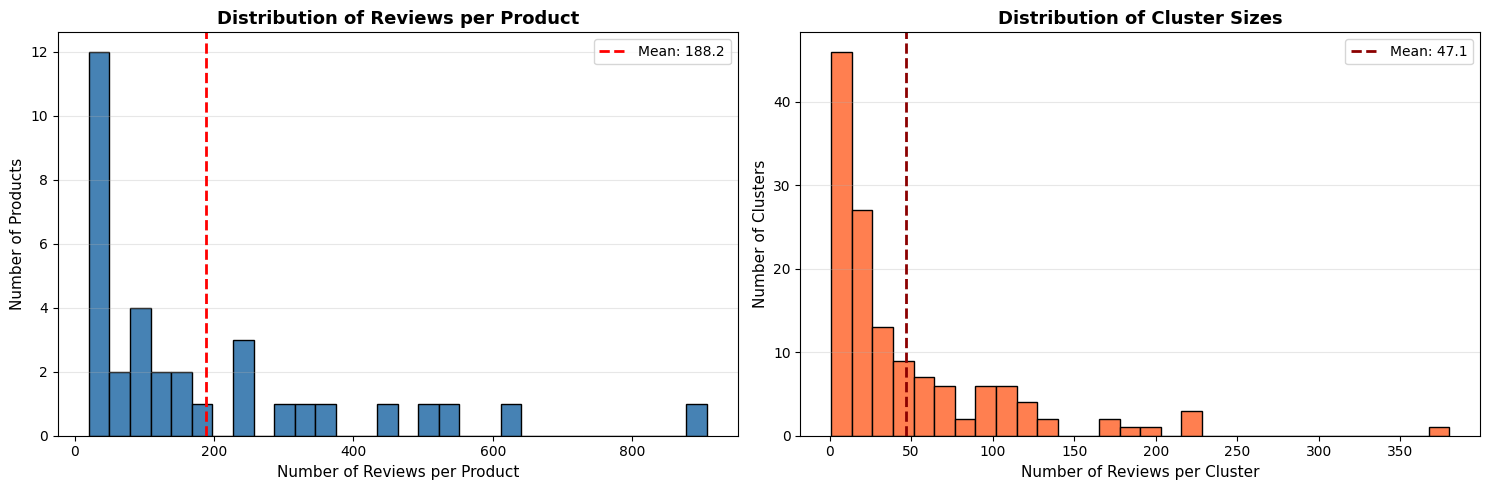

Review distribution summary:
Reviews per product - Mean: 188.24, Median: 104
Reviews per cluster - Mean: 47.06, Median: 26


In [8]:
"""
Step 7: Visualization - Distribution Analysis

Visualize how reviews are distributed across products and clusters
"""

# Plot 1: Reviews per product distribution
reviews_per_product_clustered = df_clustered['Product Name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Reviews per product
axes[0].hist(reviews_per_product_clustered.values, bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Number of Reviews per Product', fontsize=11)
axes[0].set_ylabel('Number of Products', fontsize=11)
axes[0].set_title('Distribution of Reviews per Product', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(reviews_per_product_clustered.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {reviews_per_product_clustered.mean():.1f}')
axes[0].legend()

# Right plot: Cluster sizes
cluster_sizes = df_clustered.groupby(['Product Name', 'cluster_id']).size()
axes[1].hist(cluster_sizes.values, bins=30, edgecolor='black', color='coral')
axes[1].set_xlabel('Number of Reviews per Cluster', fontsize=11)
axes[1].set_ylabel('Number of Clusters', fontsize=11)
axes[1].set_title('Distribution of Cluster Sizes', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axvline(cluster_sizes.mean(), color='darkred', linestyle='--',
                linewidth=2, label=f'Mean: {cluster_sizes.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Review distribution summary:")
print(f"Reviews per product - Mean: {reviews_per_product_clustered.mean():.2f}, Median: {reviews_per_product_clustered.median():.0f}")
print(f"Reviews per cluster - Mean: {cluster_sizes.mean():.2f}, Median: {cluster_sizes.median():.0f}")

In [9]:
"""
Step 8: Select Representative Reviews per Cluster

For each cluster, select the review closest to the cluster centroid as the representative.
This is the core of data reduction - replacing many reviews with one representative review.
"""

print("Selecting representative reviews for each cluster...")
representative_reviews = []

# For each product and cluster combination
for (product_name, cluster_id), group in tqdm(
    df_clustered.groupby(['Product Name', 'cluster_id']),
    desc="Finding representatives"
):
    # Get the review indices and embeddings for this cluster
    cluster_indices = group.index.to_numpy()
    cluster_embeddings = embeddings[cluster_indices]

    # Calculate the centroid (mean) of all embeddings in this cluster
    centroid = cluster_embeddings.mean(axis=0)

    # Find the review closest to the centroid (most representative)
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    closest_idx = cluster_indices[distances.argmin()]

    # Store the representative review
    representative_reviews.append(df_filtered.loc[closest_idx])

# Create dataframe of representative reviews
df_representatives = pd.DataFrame(representative_reviews).reset_index(drop=True)

print(f"\nREPRESENTATIVE REVIEWS SELECTED")
print(f"Original reviews: {len(df_clustered):,}")
print(f"Representative reviews: {len(df_representatives):,}")
print(f"Compression ratio: {len(df_clustered) / len(df_representatives):.2f}x")
print(f"Storage reduction: {(1 - len(df_representatives)/len(df_clustered))*100:.2f}%")

# Show sample representative reviews
print(f"\nSample representative reviews:")
print(df_representatives[['Product Name', 'Rating', 'cluster_id', 'Reviews']].head(10))

Selecting representative reviews for each cluster...


Finding representatives: 100%|██████████| 136/136 [00:00<00:00, 2081.05it/s]


REPRESENTATIVE REVIEWS SELECTED
Original reviews: 6,400
Representative reviews: 136
Compression ratio: 47.06x
Storage reduction: 97.88%

Sample representative reviews:
                                        Product Name  Rating  cluster_id  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       2           0   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       1           1   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       4           2   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...       5           3   
4  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       4           0   
5  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       5           1   
6  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       5           2   
7  "Nokia Asha 302 Unlocked GSM Phone with 3.2MP ...       5           3   
8  (LANDVO) 5.0" Capacitive Touch MTK6582 Quad Co...       3           0   
9  (LANDVO) 5.0" Capacitive Touch MTK6582 Quad Co...       5           

In [10]:
"""
Step 9: Save Results to CSV Files

Export the clustered data and representative reviews for further analysis or RAG systems.
"""

# Create output directory
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# File 1: All clustered reviews with cluster IDs
# This shows how every review was assigned to a cluster
clustered_reviews_path = os.path.join(output_dir, "clustered_reviews.csv")
df_clustered.to_csv(clustered_reviews_path, index=False)

# File 2: Representative reviews only (one per cluster)
# This is the reduced dataset for RAG or downstream tasks
representatives_path = os.path.join(output_dir, "cluster_representatives.csv")
df_representatives.to_csv(representatives_path, index=False)

# File 3: Clustering summary statistics
summary_path = os.path.join(output_dir, "clustering_summary.txt")
with open(summary_path, 'w') as f:
    f.write("CRAG Clustering Implementation - Summary Report\n")
    f.write(f"Dataset: Amazon Unlocked Mobile Reviews\n")
    f.write(f"Clustering Algorithm: K-Means (k={k})\n")
    f.write(f"Embedding Model: {model_name}\n\n")
    f.write(f"Results:\n")
    f.write(f"Total products clustered: {df_clustered['Product Name'].nunique():,}\n")
    f.write(f"Total reviews clustered: {len(df_clustered):,}\n")
    f.write(f"Total clusters created: {len(df_representatives):,}\n")
    f.write(f"Average silhouette score: {avg_silhouette:.4f}\n")
    f.write(f"Data reduction: {reduction_percent:.2f}%\n")
    f.write(f"Compression ratio: {len(df_clustered) / len(df_representatives):.2f}x\n")

print(f"\nFILES SAVED SUCCESSFULLY")
print(f"{clustered_reviews_path}")
print(f"All reviews with cluster assignments ({len(df_clustered):,} rows)")
print(f"\n{representatives_path}")
print(f"Representative reviews for RAG ({len(df_representatives):,} rows)")
print(f"Use this file for efficient retrieval systems!")
print(f"\n{summary_path}")
print(f"Summary statistics and metrics")



FILES SAVED SUCCESSFULLY
outputs/clustered_reviews.csv
All reviews with cluster assignments (6,400 rows)

outputs/cluster_representatives.csv
Representative reviews for RAG (136 rows)
Use this file for efficient retrieval systems!

outputs/clustering_summary.txt
Summary statistics and metrics


Alternative Clustering Algorithm Comparison

The cells below demonstrate how to compare K-Means with other clustering algorithms like Hierarchical Clustering.

In [11]:
"""
Step 10: Example - Single Product Deep Dive

Analyze clustering results for one specific product in detail.
This helps visualize what the clustering actually does.
"""

# Select a product with many reviews for detailed analysis
example_product = df_clustered['Product Name'].value_counts().index[0]
product_data = df_clustered[df_clustered['Product Name'] == example_product].copy()

print(f"Deep dive for product: {example_product}")
print(f"Total reviews: {len(product_data)}")
print(f"\nReviews per cluster:")
print(product_data['cluster_id'].value_counts().sort_index())

# Show sample reviews from each cluster

print("\nSAMPLE REVIEWS FROM EACH CLUSTER")


for cluster_id in sorted(product_data['cluster_id'].unique()):
    cluster_reviews = product_data[product_data['cluster_id'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_reviews)} reviews)")

    # Show 3 random reviews from this cluster
    sample_reviews = cluster_reviews.sample(min(3, len(cluster_reviews)))
    for idx, (_, row) in enumerate(sample_reviews.iterrows(), 1):
        review_text = str(row['Reviews'])[:150]  # First 150 chars
        print(f"{idx}. Rating: {row['Rating']} | {review_text}...")

    # Show the representative review
    rep_review = df_representatives[
        (df_representatives['Product Name'] == example_product) &
        (df_representatives['cluster_id'] == cluster_id)
    ]
    if not rep_review.empty:
        rep_text = str(rep_review.iloc[0]['Reviews'])[:150]
        print(f"REPRESENTATIVE: {rep_text}...")

Deep dive for product: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)
Total reviews: 907

Reviews per cluster:
cluster_id
0    112
1    223
2    380
3    192
Name: count, dtype: int64

SAMPLE REVIEWS FROM EACH CLUSTER

Cluster 0 (112 reviews)
1. Rating: 5 | What are u waiting for its ether between this or the moto g...
2. Rating: 5 | Good...
3. Rating: 5 | For the prize its wonderfull...
REPRESENTATIVE: Very good...

Cluster 1 (223 reviews)
1. Rating: 5 | Bought the phone for my daughter who is a teenager now. Nice phone and for this price, you don't need to worry about it too much.The phone itself is p...
2. Rating: 5 | Awesome phone. Had to return it due to signal issues. I will probably buy it again after some updates get released....
3. Rating: 5 | Awesome phone...
REPRESENTATIVE: Great phone for the price paid....

Cluster 2 (380 reviews)
1. Rating: 4 | I got this at the current price of $250, which is still a good deal for 

In [12]:
"""
Step 11: Hierarchical Clustering Comparison

Compare K-Means with Hierarchical (Agglomerative) Clustering.
This provides an alternative clustering method for your comparison.
"""

from sklearn.cluster import AgglomerativeClustering

# Select one product to compare clustering methods
comparison_product = df_clustered['Product Name'].value_counts().index[0]
comp_data = df_clustered[df_clustered['Product Name'] == comparison_product].copy()
comp_indices = comp_data.index.to_numpy()
comp_embeddings = embeddings[comp_indices]

print(f"Comparing clustering algorithms for: {comparison_product}")
print(f"Number of reviews: {len(comp_data)}\n")

# K-Means (already done)
kmeans_labels = comp_data['cluster_id'].to_numpy()
kmeans_sil = silhouette_score(comp_embeddings, kmeans_labels)

# Hierarchical Clustering
print("Running Hierarchical Clustering...")
hierarchical = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)
hier_labels = hierarchical.fit_predict(comp_embeddings)
hier_sil = silhouette_score(comp_embeddings, hier_labels)

# Compare results
print(f"CLUSTERING COMPARISON RESULTS")
print(f"K-Means:")
print(f"Silhouette Score: {kmeans_sil:.4f}")
print(f"Cluster distribution: {np.bincount(kmeans_labels)}")
print(f"\nHierarchical (Ward):")
print(f"Silhouette Score: {hier_sil:.4f}")
print(f"Cluster distribution: {np.bincount(hier_labels)}")

if hier_sil > kmeans_sil:
    print(f"\nHierarchical clustering performs better (+{(hier_sil - kmeans_sil):.4f})")
else:
    print(f"\nK-Means performs better (+{(kmeans_sil - hier_sil):.4f})")


Comparing clustering algorithms for: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)
Number of reviews: 907

Running Hierarchical Clustering...
CLUSTERING COMPARISON RESULTS
K-Means:
Silhouette Score: 0.0440
Cluster distribution: [112 223 380 192]

Hierarchical (Ward):
Silhouette Score: 0.0074
Cluster distribution: [128 560 131  88]

K-Means performs better (+0.0366)


Elbow Method analysis for: ALCATEL OneTouch Idol 3 Global Unlocked 4G LTE Smartphone, 5.5 HD IPS Display, 16GB (GSM - US Warranty)
Testing k from 2 to 10...



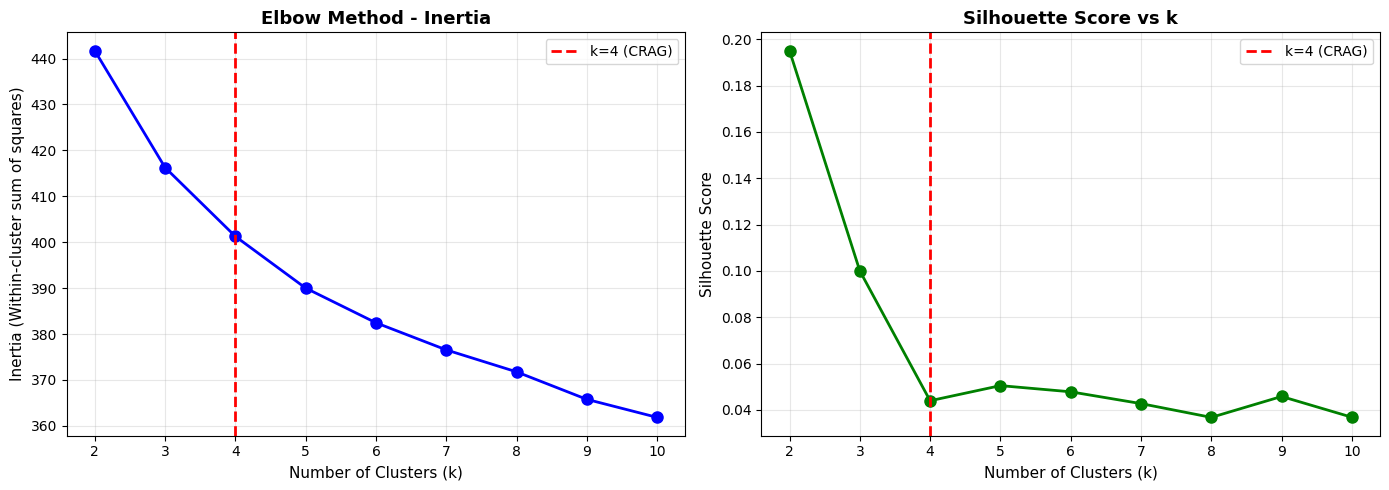


Best k based on silhouette score: 2 (score: 0.1951)
CRAG paper used k=4 (score: 0.0440)

The elbow in the inertia plot suggests the point where adding more clusters
doesn't significantly improve the clustering quality.


In [13]:
"""
Step 12 : Elbow Method for Optimal K

Use the Elbow Method to determine if k=4 is optimal.
The CRAG paper used this method to select k=4.
"""

# Select one product for elbow analysis
elbow_product = df_clustered['Product Name'].value_counts().index[0]
elbow_data = df_clustered[df_clustered['Product Name'] == elbow_product].copy()
elbow_indices = elbow_data.index.to_numpy()
elbow_embeddings = embeddings[elbow_indices]

print(f"Elbow Method analysis for: {elbow_product}")
print(f"Testing k from 2 to 10...\n")

# Test different values of k
k_range = range(2, 11)
inertias = []
silhouettes = []

for k_test in k_range:
    # Run K-Means
    km_test = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(elbow_embeddings)

    # Calculate metrics
    inertias.append(km_test.inertia_)  # Sum of squared distances to closest cluster center
    silhouettes.append(silhouette_score(elbow_embeddings, labels_test))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot (Inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=2, label='k=4 (CRAG)')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow Method - Inertia', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=2, label='k=4 (CRAG)')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Find optimal k based on silhouette
optimal_k = k_range[np.argmax(silhouettes)]
print(f"\nBest k based on silhouette score: {optimal_k} (score: {max(silhouettes):.4f})")
print(f"CRAG paper used k=4 (score: {silhouettes[2]:.4f})")
print(f"\nThe elbow in the inertia plot suggests the point where adding more clusters")
print(f"doesn't significantly improve the clustering quality.")